In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             classification_report)
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

# Preprocessing

In [2]:
# Charger les données 
df = pd.read_csv("../data/01_raw/Churn_Modelling.csv")

# Preprocessing
df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

X = df_clean.drop('Exited', axis=1)
y = df_clean['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

cat_features = ['Geography', 'Gender']

print("Données prêtes !")
print(f"Train : {X_train.shape} | Test : {X_test.shape}")

Données prêtes !
Train : (8000, 10) | Test : (2000, 10)


# Entraînement CatBoost 

In [4]:
# Entraînement
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    class_weights={0: 1, 1: 4},
    cat_features=cat_features,
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50
)

print("Entraînement terminé !")

0:	test: 0.8310714	best: 0.8310714 (0)	total: 60.9ms	remaining: 1m
100:	test: 0.8742471	best: 0.8742471 (100)	total: 565ms	remaining: 5.03s
200:	test: 0.8737443	best: 0.8749643 (167)	total: 1.05s	remaining: 4.17s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8749643326
bestIteration = 167

Shrink model to first 168 iterations.
Entraînement terminé !


# Calculer toutes les métriques

MÉTRIQUES
Accuracy  : 0.8050
ROC-AUC   : 0.8750
F1 Score  : 0.6191
Recall    : 0.7789
Precision : 0.5138

RAPPORT DÉTAILLÉ
              precision    recall  f1-score   support

       Reste       0.93      0.81      0.87      1593
       Churn       0.51      0.78      0.62       407

    accuracy                           0.81      2000
   macro avg       0.72      0.80      0.74      2000
weighted avg       0.85      0.81      0.82      2000



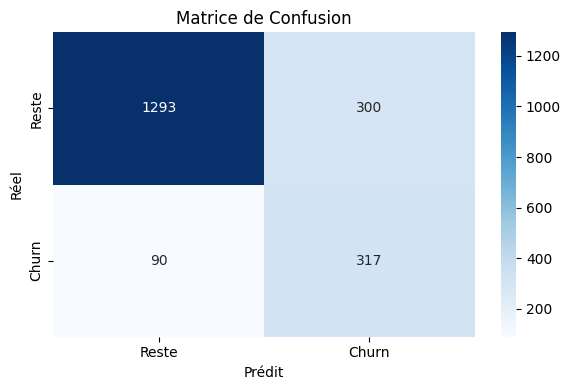

In [7]:
# Prédictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Métriques
print("MÉTRIQUES")
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")

print("\nRAPPORT DÉTAILLÉ")
print(classification_report(y_test, y_pred,
      target_names=['Reste', 'Churn']))

# Matrice de confusion
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Reste', 'Churn'],
            yticklabels=['Reste', 'Churn'],
            cmap='Blues')
plt.title('Matrice de Confusion')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

# Optuna

In [14]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'cat_features': cat_features,
        'eval_metric': 'AUC',
        'random_seed': 42,
        'verbose': 0
    }

    # Cross-validation manuelle
    kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    auc_scores = []

    for train_idx, val_idx in kf.split(X_train, y_train):
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model = CatBoostClassifier(**params)
        model.fit(X_tr, y_tr)

        y_proba = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_proba)
        auc_scores.append(auc)

    return np.mean(auc_scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30,
               show_progress_bar=True)

print(f"\nMeilleur AUC : {study.best_value:.4f}")
print(f"Meilleurs paramètres : {study.best_params}")

  0%|          | 0/30 [00:00<?, ?it/s]


Meilleur AUC : 0.8691
Meilleurs paramètres : {'iterations': 550, 'learning_rate': 0.0262889763765008, 'depth': 4, 'l2_leaf_reg': 5.113004907454704}


In [18]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        # Laisser Optuna trouver le bon poids pour la classe minoritaire
        'class_weights': {
            0: 1,
            1: trial.suggest_int('class_weight_minority', 2, 8)
        },
        'cat_features': cat_features,
        'eval_metric': 'AUC',
        'random_seed': 42,
        'verbose': 0
    }

    kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    recall_scores = []

    for train_idx, val_idx in kf.split(X_train, y_train):
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model = CatBoostClassifier(**params)
        model.fit(X_tr, y_tr)

        y_pred = model.predict(X_val)
        recall = recall_score(y_val, y_pred)
        recall_scores.append(recall)

    return np.mean(recall_scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30,
               show_progress_bar=True)

print(f"\nMeilleur Recall : {study.best_value:.4f}")
print(f"Meilleurs paramètres : {study.best_params}")

  0%|          | 0/30 [00:00<?, ?it/s]


Meilleur Recall : 0.9239
Meilleurs paramètres : {'iterations': 121, 'learning_rate': 0.010264053219532903, 'depth': 4, 'l2_leaf_reg': 7.754260911994358, 'class_weight_minority': 8}


# Modèle final avec les meilleurs paramètres

In [15]:
# Avec opt. AUC
# Modèle final avec paramètres Optuna
best_params = study.best_params
best_params['cat_features'] = cat_features
best_params['eval_metric'] = 'AUC'
best_params['random_seed'] = 42
best_params['verbose'] = 100

model_optimized = CatBoostClassifier(**best_params)

model_optimized.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50
)

# Métriques finales
y_pred = model_optimized.predict(X_test)
y_proba = model_optimized.predict_proba(X_test)[:, 1]

print(f"\nAUC     : {roc_auc_score(y_test, y_proba):.4f}")
print(f"Recall  : {recall_score(y_test, y_pred):.4f}")
print(f"F1      : {f1_score(y_test, y_pred):.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['Reste', 'Churn'])}")

0:	test: 0.7780084	best: 0.7780084 (0)	total: 5.47ms	remaining: 3s
100:	test: 0.8653538	best: 0.8653538 (100)	total: 458ms	remaining: 2.04s
200:	test: 0.8728405	best: 0.8728405 (200)	total: 900ms	remaining: 1.56s
300:	test: 0.8750199	best: 0.8750615 (299)	total: 1.33s	remaining: 1.1s
400:	test: 0.8755072	best: 0.8757725 (374)	total: 1.76s	remaining: 656ms
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8757725368
bestIteration = 374

Shrink model to first 375 iterations.

AUC     : 0.8758
Recall  : 0.4791
F1      : 0.6000

              precision    recall  f1-score   support

       Reste       0.88      0.97      0.92      1593
       Churn       0.80      0.48      0.60       407

    accuracy                           0.87      2000
   macro avg       0.84      0.72      0.76      2000
weighted avg       0.86      0.87      0.86      2000



In [20]:
# Avec opt. Recall
best_params = study.best_params
class_weight_minority = best_params.pop('class_weight_minority')

best_params['class_weights'] = {0: 1, 1: class_weight_minority}
best_params['cat_features'] = cat_features
best_params['eval_metric'] = 'AUC'
best_params['random_seed'] = 42
best_params['verbose'] = 100

model_final = CatBoostClassifier(**best_params)

model_final.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50
)

y_pred = model_final.predict(X_test)
y_proba = model_final.predict_proba(X_test)[:, 1]

print(f"\nAUC       : {roc_auc_score(y_test, y_proba):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"F1        : {f1_score(y_test, y_pred):.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['Reste', 'Churn'])}")

0:	test: 0.7471647	best: 0.7471647 (0)	total: 3.08ms	remaining: 369ms
100:	test: 0.8424542	best: 0.8426732 (97)	total: 148ms	remaining: 29.4ms
120:	test: 0.8436989	best: 0.8439426 (116)	total: 177ms	remaining: 0us

bestTest = 0.8439425558
bestIteration = 116

Shrink model to first 117 iterations.

AUC       : 0.8439
Recall    : 0.9312
Precision : 0.2873
F1        : 0.4392

              precision    recall  f1-score   support

       Reste       0.96      0.41      0.57      1593
       Churn       0.29      0.93      0.44       407

    accuracy                           0.52      2000
   macro avg       0.62      0.67      0.51      2000
weighted avg       0.82      0.52      0.55      2000

